**Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix


**Load dataset**

In [ ]:
df=pd.read_csv('/content/car data.csv')

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


**Data Cleaning and data Preprocessing**

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

**Remove Categorical Columns**

In [ ]:
df=df.drop(['Car_Name'],axis=1)

**Use one hot encoding**

**convert categorical column into numerical column**

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


**Defining features and target**

In [ ]:
X=df.drop(['Selling_Price'],axis=1)
y=df['Selling_Price']

**Train Test split for model evaluation**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

**Applying LinearRegression Alogorithm**

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

**Model Prediction**

In [ ]:
y_pred=model.predict(X_test)

**Evaluating model accuracy**

In [ ]:
accuracy=r2_score(y_test,y_pred)

In [ ]:
print(accuracy*100,'%')

91.44342972228277 %


**Import Libraries**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

**Applying RandomForestRegressor**

In [ ]:
model_rf=RandomForestRegressor(n_estimators=100,random_state=42)


In [ ]:
model_rf=RandomForestRegressor()
model_rf.fit(X_train,y_train)

RandomForestRegressor()

**Model Prediction**

In [ ]:
y_pred_rf=model_rf.predict(X_test)

**Evaluting Model accuracy**

In [ ]:
accuracy_rf=r2_score(y_test,y_pred_rf)

In [ ]:
print(accuracy_rf*100,'%')

96.25710016815312 %


**Histogram**

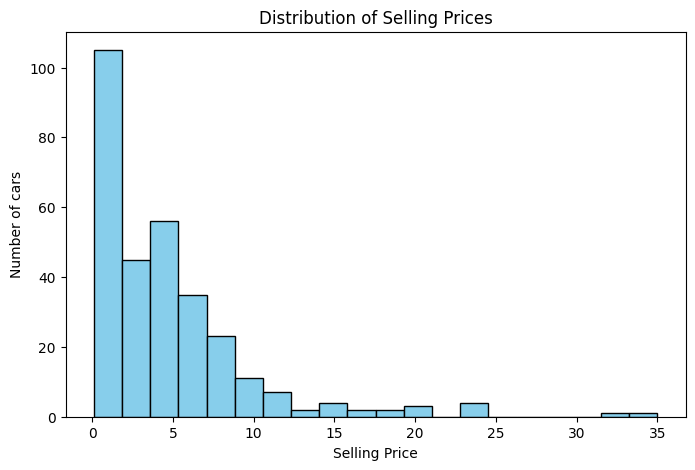

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['Selling_Price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of cars')
plt.show()


**Bar plot**

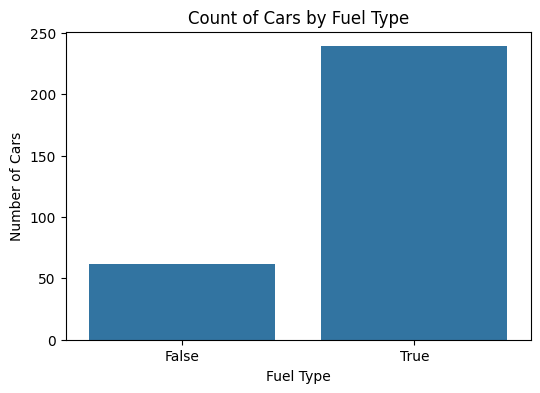

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Fuel_Type_Petrol', data=df)
plt.title('Count of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.show()

**Box PLot**

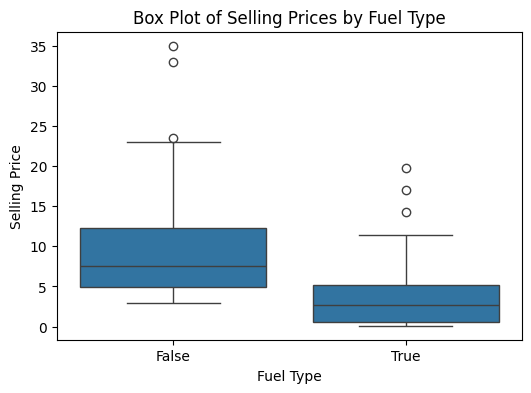

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Fuel_Type_Petrol', y='Selling_Price', data=df)
plt.title('Box Plot of Selling Prices by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

**Scatter plot**

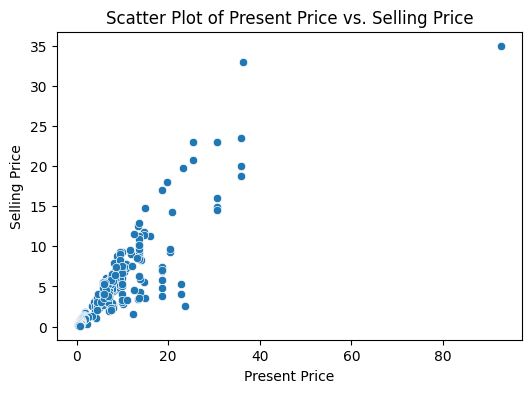

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title('Scatter Plot of Present Price vs. Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

**Correlation Heatmap**

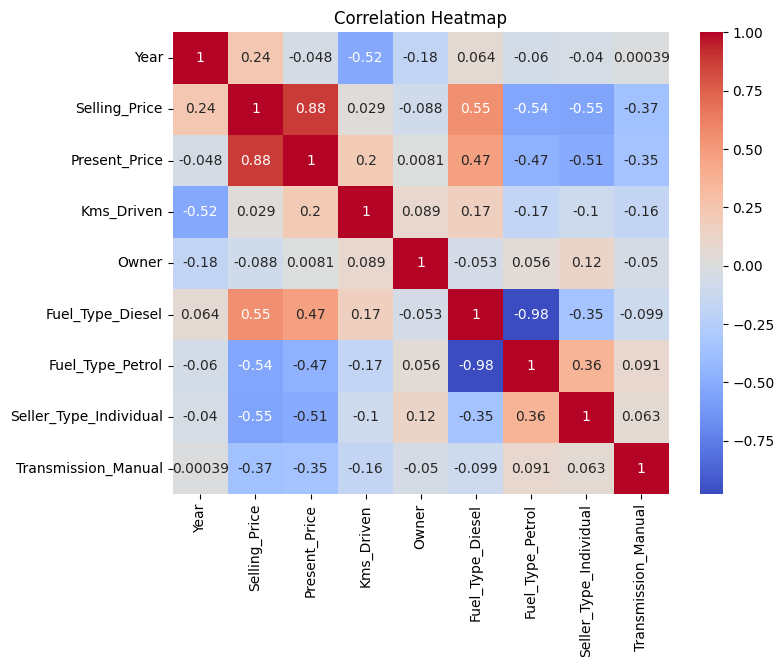

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Feature Importance**

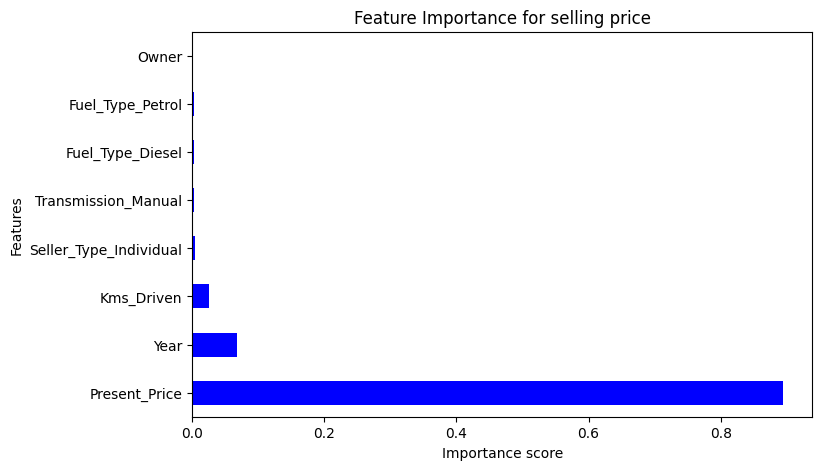

In [ ]:
importances=pd.Series(model_rf.feature_importances_, index=X.columns)
importances=importances.sort_values(ascending=False)
plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='blue')
plt.title('Feature Importance for selling price')
plt.xlabel('Importance score')
plt.ylabel('Features')
plt.show()

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np

# Save the streamlit app to a file
with open('car_app.py', 'w') as f:
    f.write('''
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# --- Load and Preprocess Data (to match notebook state) ---
df = pd.read_csv('/content/car data.csv')
df_proc = df.drop(['Car_Name'], axis=1)
df_proc = pd.get_dummies(df_proc, drop_first=True)

X = df_proc.drop(['Selling_Price'], axis=1)
y = df_proc['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# --- Train Model ---
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# --- Streamlit UI ---
st.title("🚗 Car Price Predictor")
st.write("Enter car details to estimate the selling price based on the Random Forest model.")

col1, col2 = st.columns(2)

with col1:
    year = st.number_input("Year", min_value=2000, max_value=2024, value=2015)
    present_price = st.number_input("Present Price (Lakhs)", min_value=0.0, value=5.0)
    kms_driven = st.number_input("Kms Driven", min_value=0, value=20000)
    owner = st.selectbox("Owner Type", [0, 1, 3])

with col2:
    fuel = st.selectbox("Fuel Type", ['Petrol', 'Diesel', 'CNG'])
    seller = st.selectbox("Seller Type", ['Dealer', 'Individual'])
    trans = st.selectbox("Transmission", ['Manual', 'Automatic'])

# Prepare input for prediction
# Logic follows the get_dummies(drop_first=True) structure
fuel_diesel = 1 if fuel == 'Diesel' else 0
fuel_petrol = 1 if fuel == 'Petrol' else 0
seller_ind = 1 if seller == 'Individual' else 0
trans_man = 1 if trans == 'Manual' else 0

input_df = pd.DataFrame([[year, present_price, kms_driven, owner, fuel_diesel, fuel_petrol, seller_ind, trans_man]],
                        columns=X.columns)

if st.button("Predict Price"):
    prediction = model_rf.predict(input_df)[0]
    st.success(f"Estimated Selling Price: ₹{prediction:.2f} Lakhs")
''')

print("Streamlit code written to car_app.py")